# Within-region correlation — false positive rate

`correlate_within_region()` tests, independently within each parcel, whether subjects
with a higher value in X also have a higher value in Y across the set of X/Y maps (e.g.
subjects) -- the transpose of [`colocalize()`](bench1-1_map_surrogates_fpr.ipynb)
(which correlate *across parcels*, within a subject/map). The null is generated by
permuting *map/subject identity*, not by permuting parcels spatially -- so, there is no 
obvious mechanism by which GRF spatial smoothness (`alpha`) should affect calibration here.
This notebook checks that prediction directly, using the same GRF (Gaussian Random Field) 
methodology as the spatial null methods benchmark (Markello & Misic, 2021), across a range 
of sample sizes (subjects) from 10 to 100.

Because this is a mass-univariate test repeated once per parcel, this notebook also
benchmarks the multiple-comparison correction options exposed by
`get_within_region_correlations(mc_method=...)` -- raw per-parcel FPR, family-wise
error rate (FWER) under `maxT`/`step_maxT`, and false discovery rate (FDR) under `fdr_bh`.

> **Reference:** Markello RD & Misic B (2021). Comparing spatial null models for
> brain maps. *NeuroImage*, 236, 118052. https://doi.org/10.1016/j.neuroimage.2021.118052

> **Note:** this notebook is compute-intensive at large `N_REPS`. It is designed to be
> pre-run. For a quick smoke-test, set `N_REPS=10`.

## Benchmark design

For each `(alpha, n_subjects, method)` condition:

1. Draw **`N_REPS`** independent repetitions: for each, sample `2 * n_subjects`
   GRF maps from the `alpha` pool *without replacement* (guaranteeing X and Y are
   independent draws, i.e. H0 -- no true correlation -- holds by construction), split
   into `n_subjects` X-maps and `n_subjects` Y-maps. GRF's `alpha > 0` pool only has
   1,000 maps, so at `n_subjects=100` (`2*100=200` maps needed per repetition) fewer
   than `N_REPS` fully-disjoint repetitions are possible without exhausting the pool;
   once exhausted, the pool is reused with a fresh random draw (fresh `rng` per
   repetition), which trades a small amount of between-repetition independence for
   being able to run `N_REPS` repetitions at every sample size.
2. Run `correlate_within_region(method=method, n_perm=N_PERM)`, then
   `get_within_region_correlations(mc_method=...)` for `fdr_bh`/`maxT`/`step_maxT`,
   and `get_within_region_correlations_omnibus(omnibus_stat=...)` for `rho`/`absrho`/
   `rho2`. `meff` is **not** available through `get_within_region_correlations()` -- it
   is evaluated here via the low-level primitives (`compute_meff`/
   `meff_sidak_correction`) directly, purely to document why it's excluded from the
   public API (see Configuration cell and Interpretation below).
3. Pool all `N_REPS * n_parcels` raw p-values per condition for the raw FPR; for the
   FWER corrections (`maxT`/`step_maxT`/`meff`-Sidak) and the omnibus test, pool the
   *any-rejection-per-repetition* / *single-test-per-repetition* indicator instead (the
   right unit for a family-wise / single-test rate); for `fdr_bh`, pool the per-parcel
   rejections directly (FDR is already parcel-level, not family-level).

### Condition grid

| axis | values |
|---|---|
| alpha | 0.0, 1.0, 2.0, 3.0 |
| n_subjects | 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100 |
| method | pearson, spearman |
| correction | none (raw), fdr_bh, maxT, step_maxT, meff (benchmark-only, not public API) |
| omnibus_stat | rho, absrho, rho2 |

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
PARC   = "Yan200"
ALPHAS = [0.0, 1.0, 2.0, 3.0]
N_SUBJ_SIZES = [10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]
METHODS = ["pearson", "spearman"]
MC_METHODS = ["fdr_bh", "maxT", "step_maxT", "meff"]
OMNIBUS_STATS = ["rho", "absrho", "rho2"]  # get_within_region_correlations_omnibus()

N_REPS   = 200   # independent repetitions per condition
N_PERM   = 1000  # subject-permutation null size per correlate_within_region() call
P_THRESH = 0.05
SEED     = 42

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from nispace import NiSpace
from nispace.datasets import fetch_reference
# meff is evaluated here via the low-level primitives directly, NOT through
# get_within_region_correlations(mc_method="meff") -- that option is deliberately
# rejected by the public API (see below): with n_subjects << n_parcels, the
# parcel-parcel correlation matrix it needs is rank-deficient and meff badly
# underestimates true effective dimensionality, giving an anti-conservative
# correction. This notebook is exactly what demonstrated that, so meff stays in the
# benchmark for documentation purposes, computed independently of the public API.
from nispace.stats.misc import compute_meff, meff_sidak_correction


def sample_disjoint(grf_alpha, n_needed, rng):
    """n_needed rows sampled without replacement from grf_alpha (reused across
    repetitions once the pool at this alpha is smaller than n_needed)."""
    n = len(grf_alpha)
    if n < n_needed:
        # pool exhausted at this alpha (e.g. alpha>0 has only 1000 maps); fall back to
        # sampling with replacement rather than failing -- see design note above
        idx = rng.choice(n, size=n_needed, replace=True)
    else:
        idx = rng.choice(n, size=n_needed, replace=False)
    return grf_alpha.iloc[idx]

In [2]:
# ── Helper functions ──────────────────────────────────────────────────────────

def run_condition(grf_alpha, n_subj, method, rep_seed):
    """One (alpha, n_subjects, method) condition -> raw p pool + per-repetition
    any-rejection indicators for each FWER correction + per-parcel rejections for FDR
    + per-repetition rejection indicators for each omnibus_stat."""
    p_pool = []
    fwer_reject = {mc: [] for mc in ["maxT", "step_maxT", "meff"]}
    fdr_reject = []
    omnibus_reject = {os: [] for os in OMNIBUS_STATS}
    subj_labels = [f"s{i}" for i in range(n_subj)]

    for rep in range(N_REPS):
        rng = np.random.default_rng(rep_seed + rep)
        draw = sample_disjoint(grf_alpha, 2 * n_subj, rng)
        X, Y = draw.iloc[:n_subj], draw.iloc[n_subj:]
        # X and Y are intentionally independent GRF draws paired positionally as
        # "subjects" -- give them shared synthetic subject labels so
        # correlate_within_region() doesn't warn about their (unrelated) original
        # GRF map index labels not matching
        X = X.set_axis(subj_labels, axis=0)
        Y = Y.set_axis(subj_labels, axis=0)
        # parcellation=None: X/Y are already Yan200-parcellated (columns carry parcel
        # labels), so no parcellation object / dist_mat / spin_mat is needed or fetched
        # -- correlate_within_region() has no spatial-null dependency at all (see
        # project_lazy_parcellation_loading memory: fit() eagerly fetches those for a
        # real `parcellation=` regardless of use, ~100x slower per repetition here)
        nsp = NiSpace(x=X, y=Y, parcellation=None, standardize=False, verbose=False, n_proc=1)
        nsp.fit()
        nsp.correlate_within_region(method=method, n_perm=N_PERM, seed=rep_seed + rep)

        out = nsp.get_within_region_correlations()
        p_pool.extend(out["p"].values.ravel().tolist())

        for mc in ["maxT", "step_maxT"]:
            out_mc = nsp.get_within_region_correlations(mc_method=mc)
            fwer_reject[mc].append(bool((out_mc["p_corr"].values <= P_THRESH).any()))

        # meff: NOT via get_within_region_correlations(mc_method="meff") -- that
        # option is deliberately rejected by the public API (see Configuration cell).
        # Computed here directly for benchmarking/documentation purposes only. Same
        # parcels-as-rows orientation as get_within_region_correlations() used to
        # apply (matches compute_meff's use elsewhere: effective number of
        # independent items being corrected -- here, parcels, not subjects).
        meff = compute_meff(X.values.T)
        _, reject_meff = meff_sidak_correction(out["p"], meff, alpha=P_THRESH)
        fwer_reject["meff"].append(bool(reject_meff.values.any()))

        out_fdr = nsp.get_within_region_correlations(mc_method="fdr_bh")
        fdr_reject.extend((out_fdr["p_corr"].values <= P_THRESH).ravel().tolist())

        # omnibus: one p-value per repetition per omnibus_stat (single global test,
        # not per-parcel) -- reuses the same stored null, no extra permutations
        for os in OMNIBUS_STATS:
            out_omni = nsp.get_within_region_correlations_omnibus(omnibus_stat=os)
            omnibus_reject[os].append(out_omni["p"] < P_THRESH)

    return {
        "p_pool": np.array(p_pool),
        "fwer_reject": {mc: np.array(v) for mc, v in fwer_reject.items()},
        "fdr_reject": np.array(fdr_reject),
        "omnibus_reject": {os: np.array(v) for os, v in omnibus_reject.items()},
    }

In [3]:
# ── Run all conditions ────────────────────────────────────────────────────────
n_pooled = N_REPS * 200  # n_parcels for Yan200
ci_lo = P_THRESH - 1.96 * np.sqrt(P_THRESH * (1 - P_THRESH) / n_pooled)
ci_hi = P_THRESH + 1.96 * np.sqrt(P_THRESH * (1 - P_THRESH) / n_pooled)
print(f"95% CI for raw-FPR pooled n={n_pooled}: [{ci_lo:.3f}, {ci_hi:.3f}]")

# one test per repetition (n=N_REPS) -- shared by FWER (any-rejection) and omnibus
# (single global test), both summarized as a per-repetition rejection rate
ci_lo_fwer = P_THRESH - 1.96 * np.sqrt(P_THRESH * (1 - P_THRESH) / N_REPS)
ci_hi_fwer = P_THRESH + 1.96 * np.sqrt(P_THRESH * (1 - P_THRESH) / N_REPS)
print(f"95% CI for FWER/omnibus pooled n={N_REPS}: [{ci_lo_fwer:.3f}, {ci_hi_fwer:.3f}]")

grf = fetch_reference("grf", parcellation=PARC, collection="ByAlpha", verbose=False)

records = []
cond_id = 0
t_start = time.time()

for alpha in ALPHAS:
    grf_a = grf.loc[f"alpha-{alpha:.1f}"]
    print(f"\n{'='*60}\nALPHA: {alpha}")

    for method in METHODS:
        for n_subj in N_SUBJ_SIZES:
            cond_id += 1
            t0 = time.time()
            out = run_condition(grf_a, n_subj, method, SEED + cond_id * 1000)

            raw_fpr = (out["p_pool"] < P_THRESH).mean()
            fdr_rate = out["fdr_reject"].mean()
            status = "OK" if ci_lo <= raw_fpr <= ci_hi else "!!"
            print(f"  {status} {method:8s} N={n_subj:<4d} alpha={alpha}  raw_FPR={raw_fpr:.3f}  "
                  f"FDR_rate={fdr_rate:.3f}  ({time.time()-t0:.0f}s, total {time.time()-t_start:.0f}s)")

            records.append({
                "alpha": alpha, "method": method, "n_subj": n_subj,
                "raw_fpr": raw_fpr, "n_pooled": len(out["p_pool"]),
                "fdr_rate": fdr_rate,
            })
            for mc in ["maxT", "step_maxT", "meff"]:
                records[-1][f"fwer_{mc}"] = out["fwer_reject"][mc].mean()
            for os in OMNIBUS_STATS:
                records[-1][f"omnibus_{os}"] = out["omnibus_reject"][os].mean()

results = pd.DataFrame(records)
print(f"\n{'='*60}\n{len(results)} conditions run in {time.time()-t_start:.0f}s total.")

95% CI for raw-FPR pooled n=40000: [0.048, 0.052]
95% CI for FWER/omnibus pooled n=200: [0.020, 0.080]

ALPHA: 0.0
  OK pearson  N=10   alpha=0.0  raw_FPR=0.048  FDR_rate=0.000  (7s, total 7s)
  OK pearson  N=15   alpha=0.0  raw_FPR=0.049  FDR_rate=0.000  (8s, total 15s)
  OK pearson  N=20   alpha=0.0  raw_FPR=0.049  FDR_rate=0.000  (10s, total 25s)
  OK pearson  N=25   alpha=0.0  raw_FPR=0.051  FDR_rate=0.000  (11s, total 36s)
  OK pearson  N=30   alpha=0.0  raw_FPR=0.050  FDR_rate=0.000  (12s, total 47s)
  OK pearson  N=40   alpha=0.0  raw_FPR=0.051  FDR_rate=0.000  (14s, total 61s)
  OK pearson  N=50   alpha=0.0  raw_FPR=0.050  FDR_rate=0.000  (16s, total 77s)
  OK pearson  N=60   alpha=0.0  raw_FPR=0.050  FDR_rate=0.000  (18s, total 95s)
  OK pearson  N=70   alpha=0.0  raw_FPR=0.052  FDR_rate=0.000  (20s, total 116s)
  OK pearson  N=80   alpha=0.0  raw_FPR=0.050  FDR_rate=0.000  (23s, total 139s)
  OK pearson  N=90   alpha=0.0  raw_FPR=0.051  FDR_rate=0.000  (29s, total 168s)
  OK 

## Results

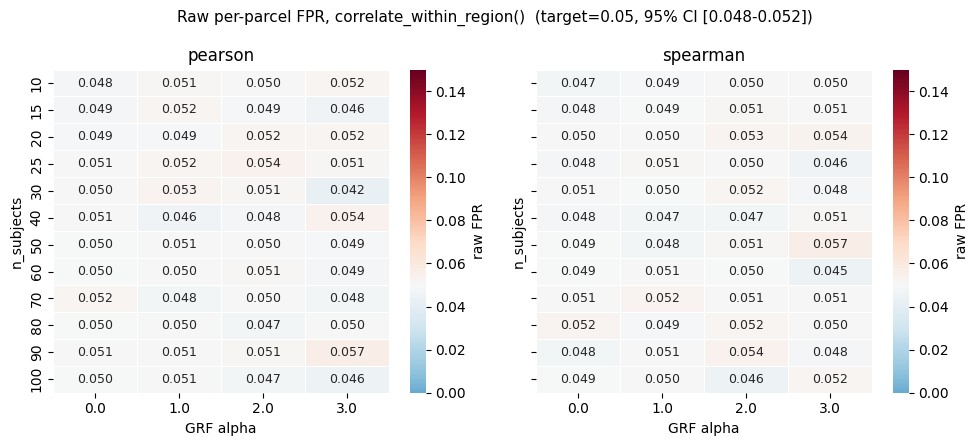

In [4]:
# Heatmap: raw FPR per (n_subj × alpha), one panel per method
fig, axes = plt.subplots(1, len(METHODS), figsize=(5*len(METHODS), 4.5), sharey=True)
for ax, method in zip(np.atleast_1d(axes), METHODS):
    sub = results[results.method == method]
    piv = sub.pivot(index="n_subj", columns="alpha", values="raw_fpr")
    sn.heatmap(piv, ax=ax, annot=True, fmt=".3f", annot_kws={"size": 9}, cmap="RdBu_r",
               vmin=0, vmax=0.15, center=P_THRESH, cbar_kws={"label": "raw FPR"}, linewidths=0.5)
    ax.set_title(method)
    ax.set_xlabel("GRF alpha")
    ax.set_ylabel("n_subjects")
fig.suptitle(f"Raw per-parcel FPR, correlate_within_region()  "
             f"(target={P_THRESH}, 95% CI [{ci_lo:.3f}-{ci_hi:.3f}])", fontsize=11)
plt.tight_layout()

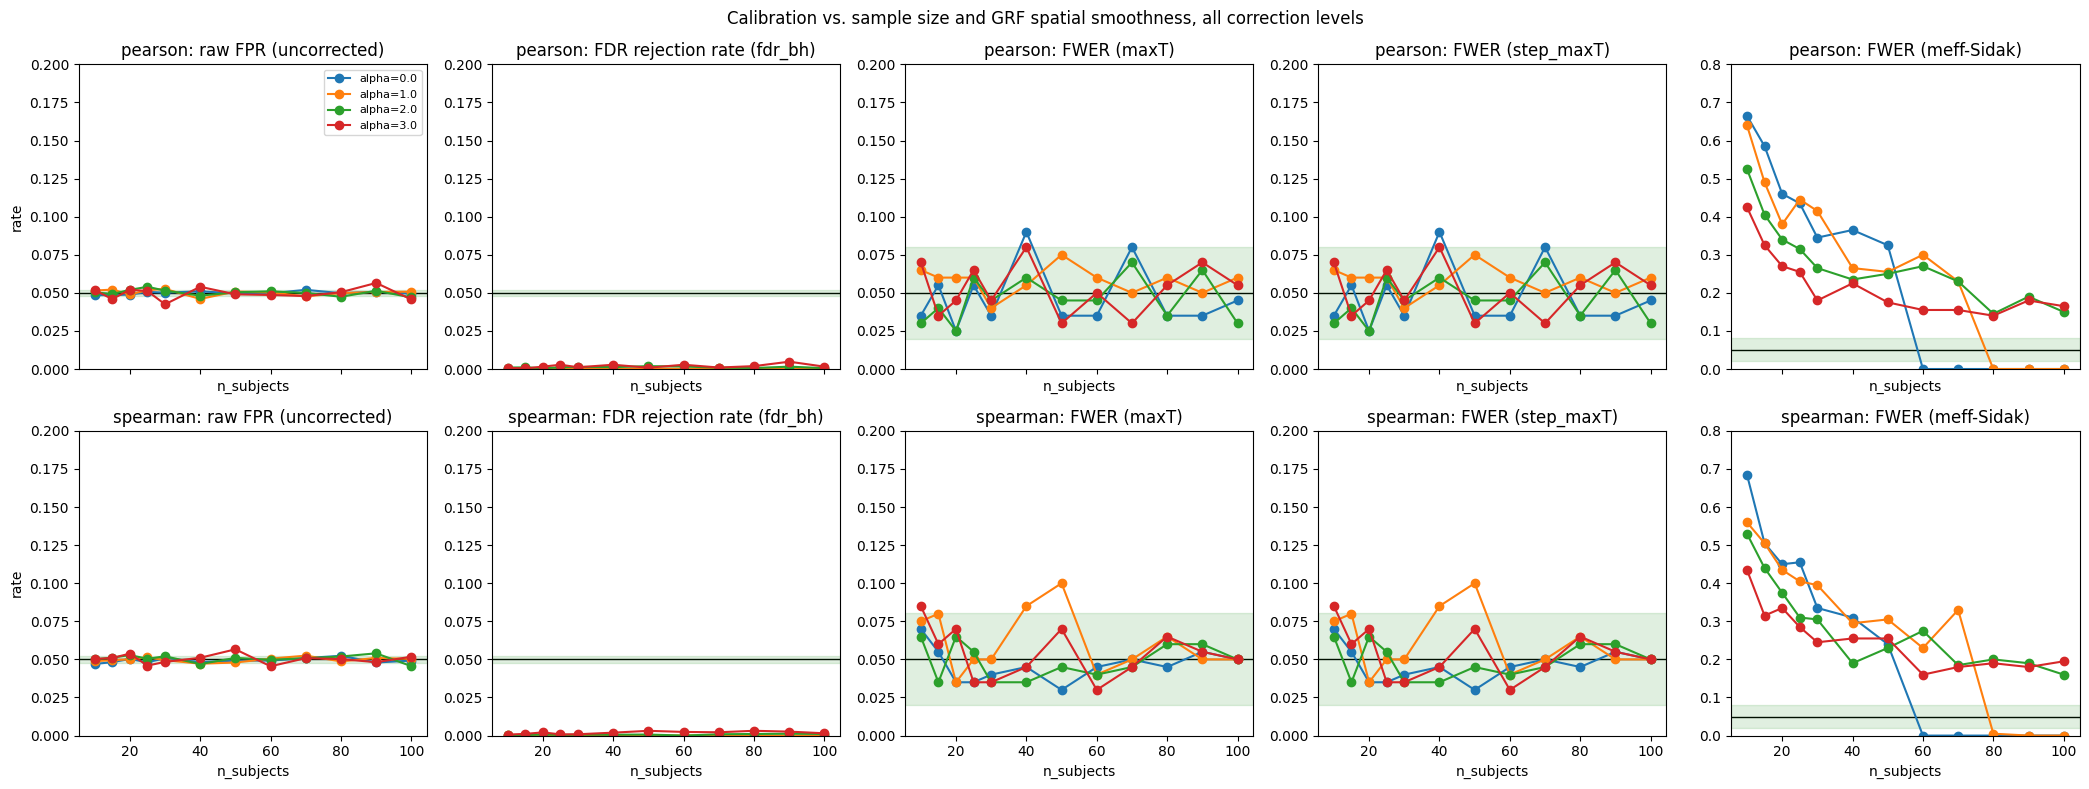

In [5]:
# Line plots: all 5 correction levels vs n_subjects, one line per alpha, split by method.
# meff gets its own (wider) y-scale -- see Interpretation, it's badly miscalibrated here
# and would otherwise be clipped/invisible on the same 0-0.2 scale as the others.
METRICS = [
    ("raw_fpr", "raw FPR (uncorrected)", (ci_lo, ci_hi), (0, 0.2)),
    ("fdr_rate", "FDR rejection rate (fdr_bh)", (ci_lo, ci_hi), (0, 0.2)),
    ("fwer_maxT", "FWER (maxT)", (ci_lo_fwer, ci_hi_fwer), (0, 0.2)),
    ("fwer_step_maxT", "FWER (step_maxT)", (ci_lo_fwer, ci_hi_fwer), (0, 0.2)),
    ("fwer_meff", "FWER (meff-Sidak)", (ci_lo_fwer, ci_hi_fwer), (0, 0.8)),
]

fig, axes = plt.subplots(len(METHODS), len(METRICS), figsize=(4.2*len(METRICS), 4*len(METHODS)),
                          sharex=True)
if len(METHODS) == 1:
    axes = axes[np.newaxis, :]

for row, method in enumerate(METHODS):
    sub = results[results.method == method]
    for col, (col_name, ylabel, ci, ylim) in enumerate(METRICS):
        ax = axes[row, col]
        for alpha, grp in sub.groupby("alpha"):
            g = grp.sort_values("n_subj")
            ax.plot(g["n_subj"], g[col_name], marker="o", label=f"alpha={alpha}")
        ax.axhline(P_THRESH, color="k", lw=1, zorder=0)
        ax.axhspan(*ci, alpha=0.12, color="green", zorder=0)
        ax.set_title(f"{method}: {ylabel}")
        ax.set_xlabel("n_subjects")
        ax.set_ylim(*ylim)
        if col == 0:
            ax.set_ylabel("rate")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
fig.suptitle("Calibration vs. sample size and GRF spatial smoothness, all correction levels",
             fontsize=12)
plt.tight_layout()

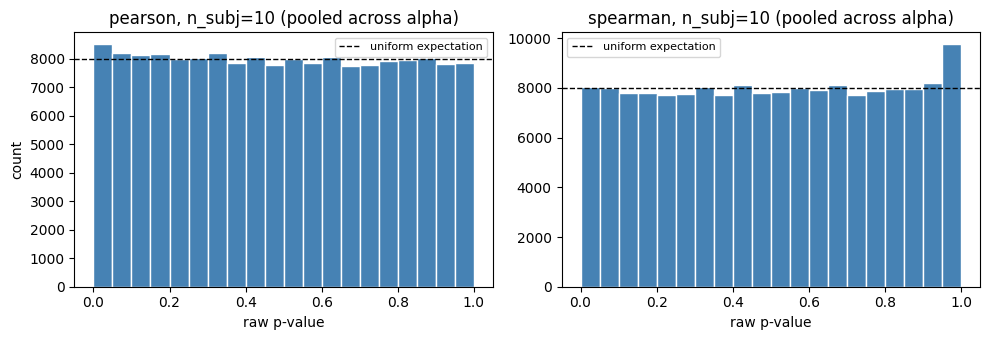

In [6]:
# p-value histograms at n_subj=10 (highest-risk small-N regime), pooled across alpha, per method
fig, axes = plt.subplots(1, len(METHODS), figsize=(5*len(METHODS), 3.5))
for ax, method in zip(np.atleast_1d(axes), METHODS):
    # `results` only stores summary FPR, not the raw pooled p-array -- rerun once,
    # cheaply, purely for the histogram
    ps = []
    for alpha in ALPHAS:
        grf_a = grf.loc[f"alpha-{alpha:.1f}"]
        out = run_condition(grf_a, 10, method, SEED + 999_000)
        ps.append(out["p_pool"])
    ps = np.concatenate(ps)
    ax.hist(ps, bins=20, range=(0, 1), color="steelblue", edgecolor="white")
    ax.axhline(len(ps) / 20, color="k", ls="--", lw=1, label="uniform expectation")
    ax.set_title(f"{method}, n_subj=10 (pooled across alpha)")
    ax.set_xlabel("raw p-value")
    ax.legend(fontsize=8)
axes[0].set_ylabel("count")
plt.tight_layout()

### Omnibus test

`get_within_region_correlations_omnibus()` collapses all per-parcel `rho` into one
number per repetition (`omnibus_stat="rho"`/`"absrho"`/`"rho2"`, see docstring) and
tests it against the same subject-permutation null, aggregated the same way -- one
p-value for the whole condition instead of one per parcel. Unlike the FDR/FWER panels
above (which summarize many per-parcel tests), this is genuinely **one test per
repetition**, so its expected calibration target is the same as raw FPR/FWER: a
rejection rate of `P_THRESH` under this benchmark's true global null, using the
FWER-style CI (`ci_lo_fwer`/`ci_hi_fwer`, `n=N_REPS`) computed above.

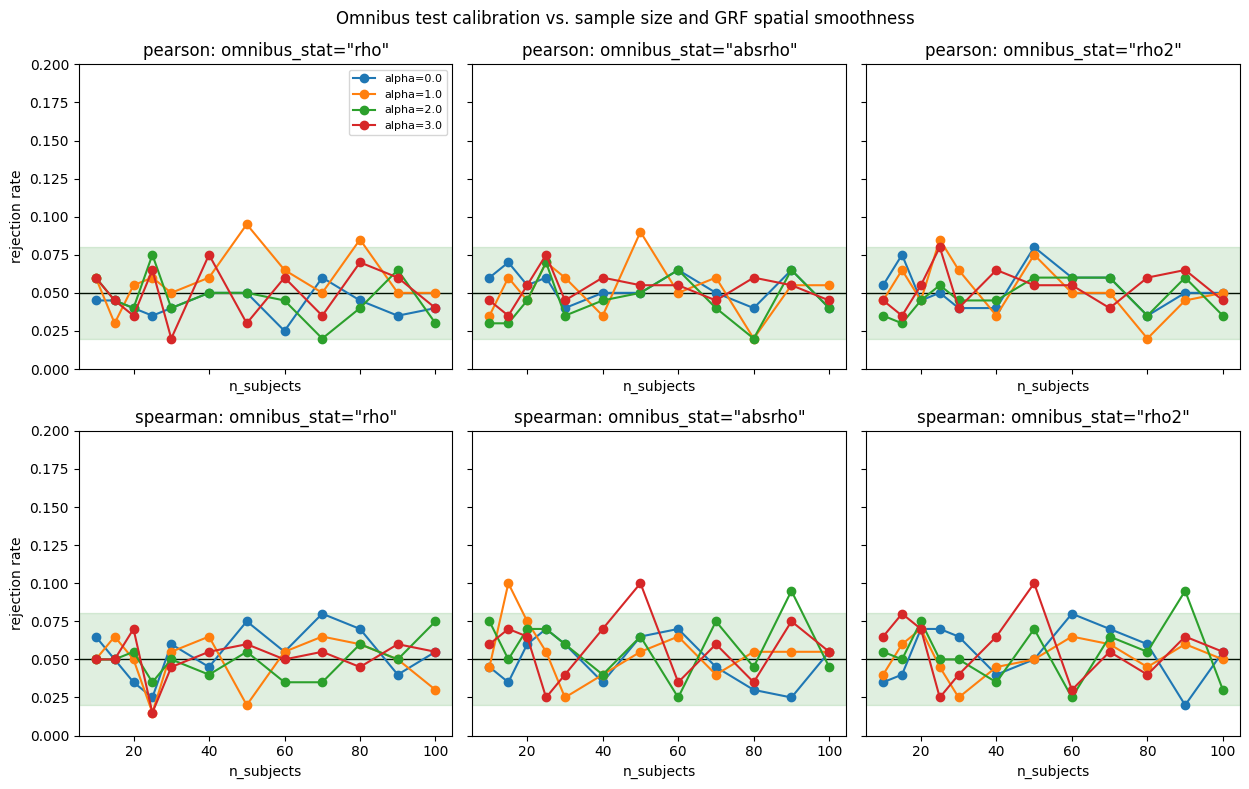

In [7]:
# Line plots: omnibus rejection rate vs n_subjects, one line per alpha, one panel per
# omnibus_stat, split by method (rows)
fig, axes = plt.subplots(len(METHODS), len(OMNIBUS_STATS),
                          figsize=(4.2*len(OMNIBUS_STATS), 4*len(METHODS)), sharex=True, sharey=True)
if len(METHODS) == 1:
    axes = axes[np.newaxis, :]

for row, method in enumerate(METHODS):
    sub = results[results.method == method]
    for col, os_ in enumerate(OMNIBUS_STATS):
        ax = axes[row, col]
        for alpha, grp in sub.groupby("alpha"):
            g = grp.sort_values("n_subj")
            ax.plot(g["n_subj"], g[f"omnibus_{os_}"], marker="o", label=f"alpha={alpha}")
        ax.axhline(P_THRESH, color="k", lw=1, zorder=0)
        ax.axhspan(ci_lo_fwer, ci_hi_fwer, alpha=0.12, color="green", zorder=0)
        ax.set_title(f"{method}: omnibus_stat=\"{os_}\"")
        ax.set_xlabel("n_subjects")
        ax.set_ylim(0, 0.2)
        if col == 0:
            ax.set_ylabel("rejection rate")
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
fig.suptitle("Omnibus test calibration vs. sample size and GRF spatial smoothness", fontsize=12)
plt.tight_layout()

## Interpretation

**Raw FPR confirms the central hypothesis: it is alpha-invariant.** Across all `n_subjects`
(10–100) and GRF spatial smoothness (`alpha` 0–3), raw per-parcel FPR stays tight around
nominal 0.05, for both `pearson` and `spearman`. The null here comes from permuting *subject
identity*, not from randomizing parcels spatially, so spatial autocorrelation in X/Y 
has no mechanism to leak into calibration here.

**`fdr_bh` near zero is expected, not a problem.** Under a complete null, BH's actual
guarantee collapses to `P(any rejection) <= alpha` -- an FWER-like quantity, not "reject ~5%
of parcels." It would behave like a normal per-parcel-rate procedure under a realistic mixture
of true and null parcels, which this FPR-only benchmark doesn't include.

**`maxT`/`step_maxT` are both well-calibrated and agree exactly on FWER.** Each takes a
per-permutation maximum `|rho|` across all parcels and compares every parcel's observed
`|rho|` against that shared null, so whatever correlation actually exists between parcels'
test statistics (spatial autocorrelation included) is preserved automatically -- no
independence assumption, unlike `bonferroni`/`fdr_bh`. Since the FWER metric here ("was *any*
parcel rejected") is entirely determined by the single most extreme parcel, and `step_maxT`'s
top-ranked computation is identical to `maxT`'s by construction, the two can never disagree on
it -- they'd only diverge on power (rejecting *additional* true positives after the first).

**`meff` is excluded from the public API, and this notebook is why.** Sidak correction via an
effective-number-of-independent-tests estimate needs a parcel-parcel correlation matrix built
from `n_subjects` observations -- far fewer than `n_parcels` (200) here -- so the estimate is
rank-deficient and systematically underestimates true dimensionality, giving an
anti-conservative correction (family-wise error well above nominal across the tested range,
improving but not reaching nominal even at the largest N). `maxT`/`step_maxT` share the exact
same prerequisite (`n_perm > 0`) at no extra cost, so there's no real tradeoff in preferring
them; `get_within_region_correlations(mc_method="meff")` raises rather than silently
returning this.

**The omnibus test (`get_within_region_correlations_omnibus()`) is expected to be
alpha-invariant and calibrated near nominal for the same structural reason as raw/maxT/
step_maxT -- it reuses the identical subject-permutation null, just aggregated across
parcels into one number per repetition instead of tested per parcel.** All three
`omnibus_stat` choices (`rho`, `absrho`, `rho2`) are single tests under this benchmark's
true global null, so each should show a rejection rate near `P_THRESH` regardless of
`alpha`, `n_subjects`, or `method`.

**The actual validity risk isn't spatial structure -- it's a shared confound.**
Subject-permutation preserves X's and Y's entire internal structure untouched (only
subject-to-subject pairing is reshuffled), so neither within-map spatial autocorrelation nor
between-subject intercorrelation threatens `raw`/`maxT`/`step_maxT` calibration, which is
exactly what the alpha-invariance above demonstrates. What none of this protects against is a
subject-level variable correlated with *both* X's and Y's between-subject variation (age,
motion, site) -- that breaks the exchangeability the permutation null relies on, not just
"adds correlation among tests." Addressing that needs a subject-indexed partial-correlation
extension (regress the confound out before testing), which we add as a feature in the future.